<a href="https://colab.research.google.com/github/AbdulkaderKharrat/AbdulkaderKharrat/blob/main/breast_cancer_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<h1>Imports</h1>**

In [ ]:
import os
from os import listdir
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from pathlib import Path

import glob
import random
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset  # Ensure Dataset is imported
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim

import cv2
from matplotlib.image import imread

import tensorflow as tf
#from keras.utils.np_utils import to_categorical
from keras.preprocessing import image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import glob
import PIL
import random

random.seed(100)

Num GPUs Available:  1


# Read Data

In [ ]:
breast_img_paths = glob.glob('/kaggle/input/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/**/*.png', recursive = True)
for img_path in breast_img_paths[:5]:
    print(img_path)

/kaggle/input/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-012.png
/kaggle/input/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-009.png
/kaggle/input/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-006.png
/kaggle/input/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-011.png
/kaggle/input/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-29960CD/200X/SOB_B_A-14-29960CD-200-004.png


# Separate the data

In [ ]:
# types of cancer
benign = []
malignant = []
# subtypes
A, F, PT, TA = [], [], [], [] # subtypes for benign
DC, LC, MC, PC = [], [], [], [] # subtypes for malignant

for img in breast_img_paths:
    img_name = Path(img).name
    if img_name[6] == 'A':
        A.append(img)
    elif img_name[6] == 'F':
        F.append(img)
    elif img_name[6] == 'P'and img_name[7] == 'T':
        PT.append(img)
    elif img_name[6] == 'T':
        TA.append(img)
    elif img_name[6] == 'D':
        DC.append(img)
    elif img_name[6] == 'L':
        LC.append(img)
    elif img_name[6] == 'M':
        MC.append(img)
    elif img_name[6] == 'P':
        PC.append(img)

    if img_name[4] == 'B':
        benign.append(img)
    else:
        malignant.append(img)


In [ ]:
print("Total examples: ", len(breast_img_paths))
print("Number of benign examples", len(benign))
print("Number of malignant examples", len(malignant))

Total examples:  7909
Number of benign examples 2480
Number of malignant examples 5429


# Sample Images From The Dataaset

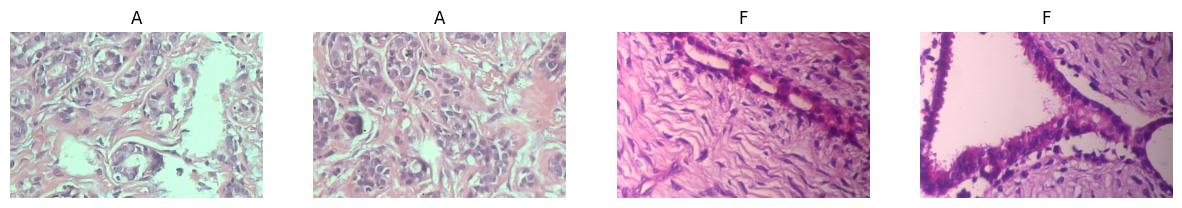

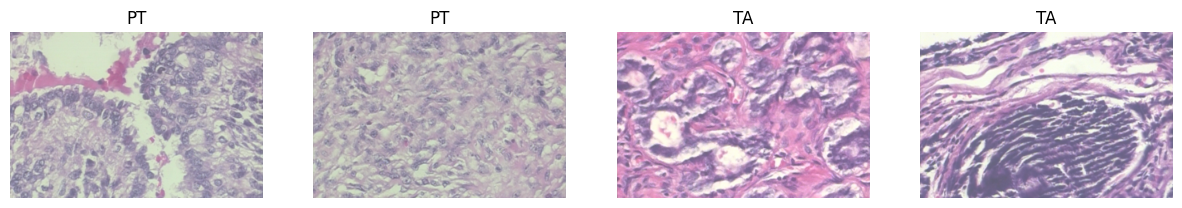

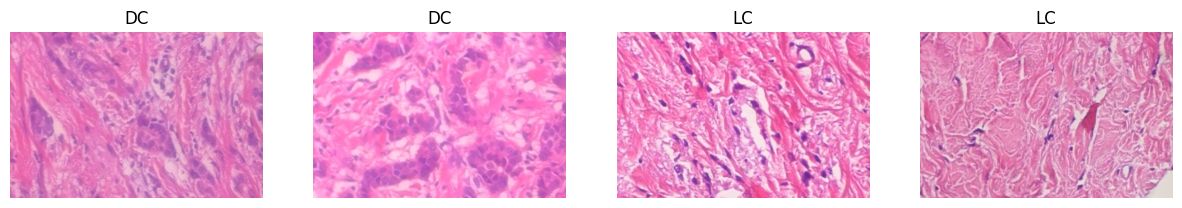

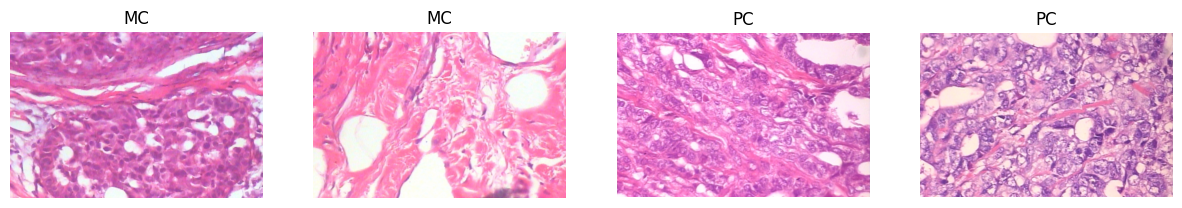

In [ ]:
import matplotlib.image as mpimg

def display_images(label1, label2, list1, list2):
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    for ax, img_path in zip(axes[:2], list1[:2]):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(label1)
        ax.axis('off')

    for ax, img_path in zip(axes[2:], list2[:2]):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(label2)
        ax.axis('off')
    plt.show()

# Display images from each list
display_images("A", "F", A, F)
display_images("PT","TA", PT, TA)
display_images("DC","LC", DC, LC)
display_images("MC","PC", MC, PC)

# Pre-Processing

In [ ]:
def load_and_resize_images(img_list, label, size=(128, 128)):
    img_array = []
    for img in img_list:
        image = cv2.imread(img, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        image = tf.convert_to_tensor(image, dtype=tf.float32)
        image = image / 255.0
        if label != 4:
            augmented_images = augment_image(image)
            for aug_img in augmented_images:
                image_resized = tf.image.resize(aug_img, size)
                img_array.append([image_resized, label])
        else:
            image_resized = tf.image.resize(image, size)
            img_array.append([image_resized, label])

    return img_array

def augment_image(img):
    augmented_images = []

    augmented_images.append(img)

    for k in [1, 2]:
        rotated_img = tf.image.rot90(img, k=k)
        mirrored_rotated_img = tf.image.flip_left_right(rotated_img)
        augmented_images.append(mirrored_rotated_img)

    return augmented_images

A_imgs  = load_and_resize_images(A, 0)
F_imgs  = load_and_resize_images(F, 1)
PT_imgs  = load_and_resize_images(PT, 2)
TA_imgs = load_and_resize_images(TA, 3)
DC_imgs = load_and_resize_images(DC, 4)
LC_imgs = load_and_resize_images(LC, 5)
MC_imgs = load_and_resize_images(MC, 6)
PC_imgs = load_and_resize_images(PC, 7)

# Undersampling majority class.

In [ ]:
data_b = A_imgs + F_imgs + PT_imgs + TA_imgs
data_m = DC_imgs + LC_imgs + MC_imgs + PC_imgs
print("Total number of benign examples:", len(data_b))
print("Total number of malignant examples:", len(data_m))

random.shuffle(data_b)
random.shuffle(data_m)

# Initial split to separate out the test set (20% of the data)
dataTrain_b, dataTest_b = train_test_split(data_b, test_size=0.2, random_state=42)

# Further split the training set into training and validation sets (75% train, 25% val of 80% train-val data)
dataTrain_b, dataVal_b = train_test_split(dataTrain_b, test_size=0.25, random_state=42)

# Initial split to separate out the test set (20% of the data)
dataTrain_m, dataTest_m = train_test_split(data_m, test_size=0.2, random_state=42)

# Further split the training set into training and validation sets (75% train, 25% val of 80% train-val data)
dataTrain_m, dataVal_m = train_test_split(dataTrain_m, test_size=0.25, random_state=42)

dataTrain_b_modified = [(image, 0) for image, label in dataTrain_b]
dataTrain_m_modified = [(image, 1) for image, label in dataTrain_m]

dataTrain = dataTrain_b_modified + dataTrain_m_modified
random.shuffle(dataTrain)

dataVal_b_modified = [(image, 0) for image, label in dataVal_b]
dataVal_m_modified = [(image, 1) for image, label in dataVal_m]

dataVal = dataVal_b_modified + dataVal_m_modified
random.shuffle(dataVal)

dataTest_b_modified = [(image, 0) for image, label in dataTest_b]
dataTest_m_modified = [(image, 1) for image, label in dataTest_m]

dataTest = dataTest_b_modified + dataTest_m_modified

print("Total number of examples:", len(dataTrain) + len(dataVal) + len(dataTest))

Total number of benign examples: 7440
Total number of malignant examples: 9385
Total number of examples: 16825


<h1> Creating A Dataset of Tensors From Image List </h1>

In [ ]:
def create_tf_dataset(img_list, batch_size=64):
    images, labels = zip(*img_list)
    images = np.array(images)  # Convert images to numpy array
    labels = np.array(labels)

    # One-hot encode labels
    labels = tf.keras.utils.to_categorical(labels, num_classes=2)

    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.shuffle(buffer_size=1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

with tf.device('/GPU:0'):
    train_dataset = create_tf_dataset(dataTrain)
    val_dataset = create_tf_dataset(dataVal)
    test_dataset = create_tf_dataset(dataTest)

# Binary Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten, Dropout, Lambda, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# Base Model
base_model = tf.keras.applications.DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)
# base_model.trainable = False
# Extract intermediate layers
layer_names = ['conv3_block12_concat', 'conv4_block24_concat', 'conv5_block16_concat']
intermediate_outputs = [base_model.get_layer(name).output for name in layer_names]

# Create a new model that outputs intermediate layers
intermediate_model = Model(inputs=base_model.input, outputs=intermediate_outputs)

# Define the branches for each intermediate output
branch_outputs = []
for output in intermediate_outputs:
    x = GlobalAveragePooling2D()(output)
    x = Lambda(lambda x: tf.math.l2_normalize(x, axis=-1))(x)
    x = Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    branch_outputs.append(x)
# Concatenate the branch outputs for score-level fusion
fusion = tf.keras.layers.Concatenate()(branch_outputs)

# Final dense layers
x = Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(fusion)
x = BatchNormalization()(x)
x = Dropout(0.45)(x)
final_output = Dense(2, activation='softmax')(x)

# Combine everything into a model
binary_model = Model(inputs=base_model.input, outputs=final_output)

optimizer = Adam(learning_rate=0.0001)

binary_model.compile(optimizer=optimizer,
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Callbacks for early stopping and learning rate scheduling
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


<h2> Binary Model Training </h2>

In [ ]:
import time

start_time = time.time()

history = binary_model.fit(train_dataset,
                           validation_data=val_dataset,
                           epochs=50,
                           callbacks=[early_stopping, reduce_lr])

end_time = time.time()

total_time = end_time - start_time
print(f"Total time taken to train the model: {total_time:.2f} seconds")

Epoch 1/50


I0000 00:00:1738999442.738336      72 service.cc:145] XLA service 0x7da580009500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738999442.738405      72 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1738999513.426935      72 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_55', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_48', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_1043', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1738999513.589321      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7450 - loss: 0.9545

I0000 00:00:1738999598.561216      72 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_52', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_45', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_1042', 4 bytes spill stores, 4 bytes spill loads



158/158 ━━━━━━━━━━━━━━━━━━━━ 231s 673ms/step - accuracy: 0.7459 - loss: 0.9525 - val_accuracy: 0.4704 - val_loss: 1.0620 - learning_rate: 1.0000e-04
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.9013 - loss: 0.6026 - val_accuracy: 0.5489 - val_loss: 0.9279 - learning_rate: 1.0000e-04
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 21s 133ms/step - accuracy: 0.9589 - loss: 0.4676 - val_accuracy: 0.8779 - val_loss: 0.6658 - learning_rate: 1.0000e-04
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 21s 133ms/step - accuracy: 0.9745 - loss: 0.4088 - val_accuracy: 0.8981 - val_loss: 0.6567 - learning_rate: 1.0000e-04
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.9856 - loss: 0.3667 - val_accuracy: 0.9132 - val_loss: 0.5826 - learning_rate: 1.0000e-04
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.9820 - loss: 0.3623 - val_accuracy: 0.9664 - val_loss: 0.3931 - learning_rate: 1.0000e-04
Epoch 7/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 20s 130ms/step -

<h2> Evaluation </h2>

In [ ]:
test_loss, test_acc = binary_model.evaluate(test_dataset)
print(f"Test accuracy (binary classification): {test_acc}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9882 - loss: 0.1494
Test accuracy (binary classification): 0.9893016219139099


# Multi-Class Classification Module
<h2> Preparing The Datasets </h2>

In [ ]:
dataTrain_m = [(image, label-4) for image, label in dataTrain_m]
dataVal_m = [(image, label-4) for image, label in dataVal_m]
dataTest_m = [(image, label-4) for image, label in dataTest_m]

In [ ]:
def create_tf_dataset(img_list, batch_size=64):
    images, labels = zip(*img_list)
    images = np.array(images)  # Convert images to numpy array
    labels = np.array(labels)

    # One-hot encode labels
    labels = tf.keras.utils.to_categorical(labels, num_classes=4)

    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.shuffle(buffer_size=1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

dataTrain_b = create_tf_dataset(dataTrain_b)
dataVal_b = create_tf_dataset(dataVal_b)
test_dataset_b = create_tf_dataset(dataTest_b)
dataTrain_m = create_tf_dataset(dataTrain_m)
dataVal_m = create_tf_dataset(dataVal_m)
test_dataset_m = create_tf_dataset(dataTest_m)

# Benign Branch

In [ ]:
# Benign Subtypes Model
base_model_b = tf.keras.applications.DenseNet121(
weights='imagenet',
include_top=False,
input_shape=(128, 128, 3)
)
# base_model_b.trainable = False
# Extract intermediate layers
layer_names = ['conv3_block12_concat', 'conv4_block24_concat', 'conv5_block16_concat']
intermediate_outputs = [base_model_b.get_layer(name).output for name in layer_names]

intermediate_model = Model(inputs=base_model_b.input, outputs=intermediate_outputs)

# Define the branches for each intermediate output
branch_outputs = []
for output in intermediate_outputs:
    x = GlobalAveragePooling2D()(output)
    x = Lambda(lambda x: tf.math.l2_normalize(x, axis=-1))(x)
    x = Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    branch_outputs.append(x)
# Concatenate the branch outputs for score-level fusion
fusion = tf.keras.layers.Concatenate()(branch_outputs)

# Final dense layers
x = Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(fusion)
x = BatchNormalization()(x)
x = Dropout(0.45)(x)
final_output = Dense(4, activation='softmax')(x)

# Combine everything into a model
benign_model = Model(inputs=base_model_b.input, outputs=final_output)

optimizer = Adam(learning_rate=0.0001)

benign_model.compile(optimizer=optimizer,
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Callbacks for early stopping and learning rate scheduling
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)


<h2> Training The Benign Subtypes Model </h2>

In [ ]:
import time

start_time = time.time()

history_b = benign_model.fit(dataTrain_b,
                    validation_data=dataVal_b,
                    epochs=50)

end_time = time.time()

total_time = end_time - start_time
print(f"Total time taken to train the model: {total_time:.2f} seconds")

Epoch 1/50


I0000 00:00:1739000542.230645      73 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_55', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_48', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_1041', 4 bytes spill stores, 4 bytes spill loads



69/70 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.4575 - loss: 1.7731

I0000 00:00:1739000617.120222      72 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_52', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_45', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_1042', 4 bytes spill stores, 4 bytes spill loads



70/70 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.4606 - loss: 1.7650 - val_accuracy: 0.1700 - val_loss: 1.7496
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.7339 - loss: 1.0723 - val_accuracy: 0.1902 - val_loss: 1.7132
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.8295 - loss: 0.8735 - val_accuracy: 0.3239 - val_loss: 1.6306
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.8903 - loss: 0.7358 - val_accuracy: 0.6667 - val_loss: 1.4353
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - accuracy: 0.9246 - loss: 0.6485 - val_accuracy: 0.7809 - val_loss: 1.2700
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - accuracy: 0.9405 - loss: 0.5991 - val_accuracy: 0.8347 - val_loss: 1.0742
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.9654 - loss: 0.5377 - val_accuracy: 0.8790 - val_loss: 0.8371
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - accuracy: 0.9760 - loss: 0.5035 - val_accuracy: 0.9133 - val_l

## Evaluation

In [ ]:
test_loss, test_acc = benign_model.evaluate(test_dataset_b)
print(f"Test accuracy -multi class for benign-: {test_acc:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9381 - loss: 0.4056
Test accuracy -multi class for benign-: 0.9483


# Malignant Branch

In [ ]:
import gc
gc.collect()

4

In [ ]:
#Malignant Subtypes Model
base_model_m = tf.keras.applications.DenseNet121(
weights='imagenet',
include_top=False,
input_shape=(128, 128, 3)
)
# base_model_m.trainable = False #freezing the DenseNet121 layers

# Extract intermediate layers
layer_names = ['conv3_block12_concat', 'conv4_block24_concat', 'conv5_block16_concat']
intermediate_outputs = [base_model_m.get_layer(name).output for name in layer_names]

intermediate_model = Model(inputs=base_model_m.input, outputs=intermediate_outputs)

# Define the branches for each intermediate output
branch_outputs = []
for output in intermediate_outputs:
    x = GlobalAveragePooling2D()(output)
    x = Lambda(lambda x: tf.math.l2_normalize(x, axis=-1))(x)
    x = Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    branch_outputs.append(x)
# Concatenate the branch outputs for score-level fusion
fusion = tf.keras.layers.Concatenate()(branch_outputs)

# Final dense layers
x = Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(fusion)
x = BatchNormalization()(x)
x = Dropout(0.45)(x)
final_output = Dense(4, activation='softmax')(x)

# Combine everything into a model
malignant_model = Model(inputs=base_model_m.input, outputs=final_output)

optimizer = Adam(learning_rate=0.0001)

malignant_model.compile(optimizer=optimizer,
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Callbacks for early stopping and learning rate scheduling
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

## Training The Malignant Subtypes Model

In [ ]:
import time

start_time = time.time()

history_m = malignant_model.fit(dataTrain_m,
                                validation_data=dataVal_m,
                                epochs=50)

end_time = time.time()

total_time = end_time - start_time
print(f"Total time taken to train the model: {total_time:.2f} seconds")

Epoch 1/50
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4159 - loss: 1.9082

I0000 00:00:1739001274.644356      70 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_49', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_slice_fusion_3', 8 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_43', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_1042', 4 bytes spill stores, 4 bytes spill loads



88/88 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.4177 - loss: 1.9026 - val_accuracy: 0.3708 - val_loss: 1.7215
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - accuracy: 0.6746 - loss: 1.1974 - val_accuracy: 0.4827 - val_loss: 1.6328
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.8029 - loss: 0.9242 - val_accuracy: 0.6319 - val_loss: 1.4464
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.8673 - loss: 0.7677 - val_accuracy: 0.7736 - val_loss: 1.2170
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - accuracy: 0.9162 - loss: 0.6537 - val_accuracy: 0.8274 - val_loss: 1.0126
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - accuracy: 0.9502 - loss: 0.5745 - val_accuracy: 0.8322 - val_loss: 0.8679
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.9594 - loss: 0.5346 - val_accuracy: 0.8732 - val_loss: 0.7578
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - accuracy: 0.9734 - loss: 0.4982 - val_accuracy: 0.8759 

## Evaluation

In [ ]:
test_loss, test_acc = malignant_model.evaluate(test_dataset_m)
print(f"Test accuracy -multi class for malignant-: {test_acc:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9275 - loss: 0.4107
Test accuracy -multi class for malignant-: 0.9265


# Hierarchial Predict

In [ ]:
def hierarchical_predict(image):
    binary_pred = binary_model.predict(np.expand_dims(image, axis=0), verbose=0)
    binary_class = np.argmax(binary_pred, axis=1)

    if binary_class == 0:  # If benign
        subtype_pred = benign_model.predict(np.expand_dims(image, axis=0),verbose=0)
        subtype_class = np.argmax(subtype_pred, axis=1)
    else:  # If malignant
        subtype_pred = malignant_model.predict(np.expand_dims(image, axis=0), verbose=0)
        subtype_class = np.argmax(subtype_pred, axis=1)

    return binary_class, subtype_class


correct_predictions = 0
total_predictions = 0

for i, data in enumerate(dataTest):
    image, binary_label = data
    predicted_binary_class, pred_multi_class = hierarchical_predict(image)

    # Compare the predicted and true combined class
    if predicted_binary_class == binary_label and ((i < len(dataTest_b) and pred_multi_class == dataTest_b[i][1]) or (i >= len(dataTest_b) and pred_multi_class == dataTest_m[i- len(dataTest_b)][1])):
        correct_predictions += 1
    total_predictions += 1

# Calculate accuracy
accuracy = correct_predictions / total_predictions
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 92.60%


# Plots

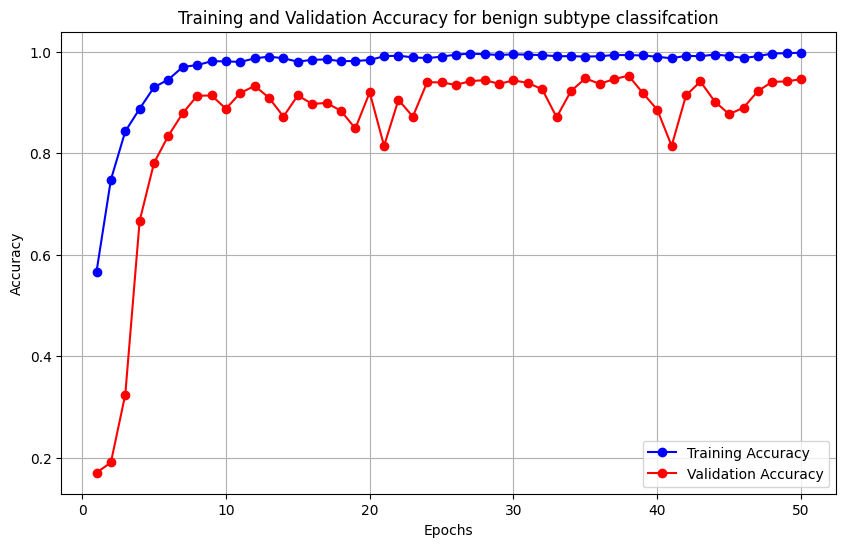

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracy data from the history object
train_acc = history_b.history['accuracy']
val_acc = history_b.history['val_accuracy']

# Create a list of epochs
epochs = range(1, len(train_acc) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy for benign subtype classifcation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

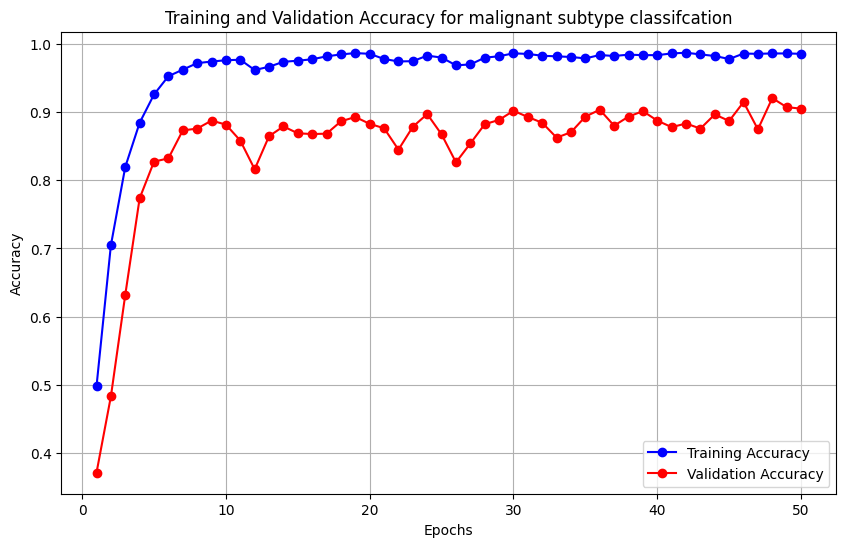

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracy data from the history object
train_acc = history_m.history['accuracy']
val_acc = history_m.history['val_accuracy']

# Create a list of epochs
epochs = range(1, len(train_acc) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy for malignant subtype classifcation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

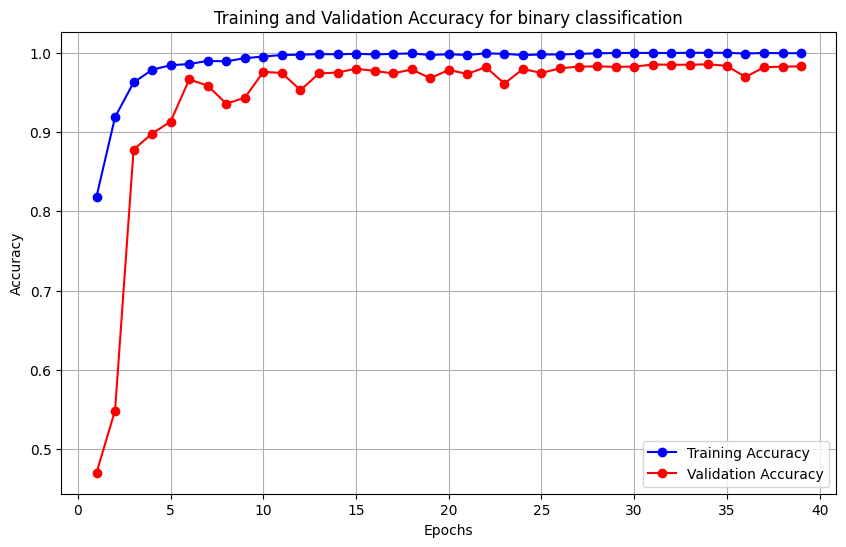

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracy data from the history object
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Create a list of epochs
epochs = range(1, len(train_acc) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy for binary classification')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Calculating Other Evaluation Metrics (Precision, Recall, and F1-Score)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

## Binary Model

In [ ]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    # Predict the classes for each image
    predictions = binary_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(labels, axis=1)

    y_true.extend(true_classes)
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute precision, recall, and F1 score for multi-class classification
precision = precision_score(y_true, y_pred, average='binary')
recall = recall_score(y_true, y_pred, average='binary')
f1 = f1_score(y_true, y_pred, average='binary')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.9888
Recall: 0.9920
F1 Score: 0.9904


## Benign Model

In [ ]:
y_true_b = []
y_pred_b = []

for images, labels in test_dataset_b:
    # Predict the classes for each image
    predictions_b = benign_model.predict(images, verbose=0)
    predicted_classes_b = np.argmax(predictions_b, axis=1)
    true_classes_b = np.argmax(labels, axis=1)

    y_true_b.extend(true_classes_b)
    y_pred_b.extend(predicted_classes_b)

y_true_b = np.array(y_true_b)
y_pred_b = np.array(y_pred_b)

precision = precision_score(y_true_b, y_pred_b, average='macro')
recall = recall_score(y_true_b, y_pred_b, average='macro')
f1 = f1_score(y_true_b, y_pred_b, average='macro')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.9475
Recall: 0.9440
F1 Score: 0.9457


## Malignant Model

In [ ]:
y_true_m = []
y_pred_m = []

for images, labels in test_dataset_m:
    # Predict the classes for each image
    predictions_m = malignant_model.predict(images, verbose=0)
    predicted_classes_m = np.argmax(predictions_m, axis=1)
    true_classes_m = np.argmax(labels, axis=1)

    y_true_m.extend(true_classes_m)
    y_pred_m.extend(predicted_classes_m)

y_true_m = np.array(y_true_m)
y_pred_m = np.array(y_pred_m)

# Compute precision, recall, and F1 score for multi-class classification
precision = precision_score(y_true_m, y_pred_m, average='macro')
recall = recall_score(y_true_m, y_pred_m, average='macro')
f1 = f1_score(y_true_m, y_pred_m, average='macro')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.9285
Recall: 0.9272
F1 Score: 0.9275


# Confusion Matrix

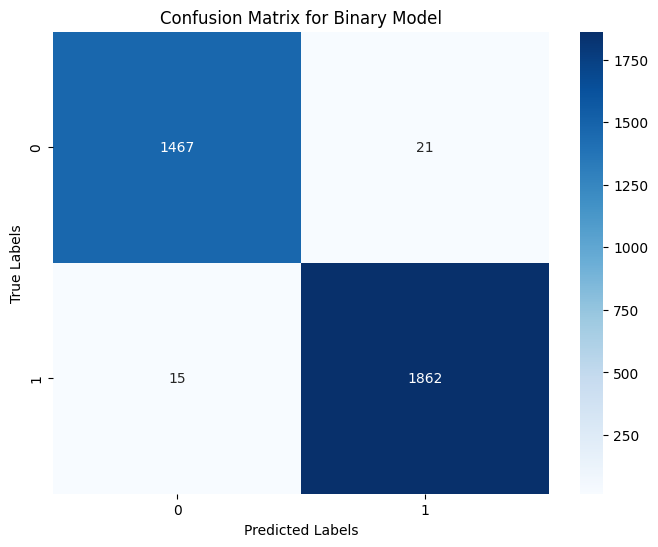

In [ ]:
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Confusion Matrix for Binary Model')
plt.show()

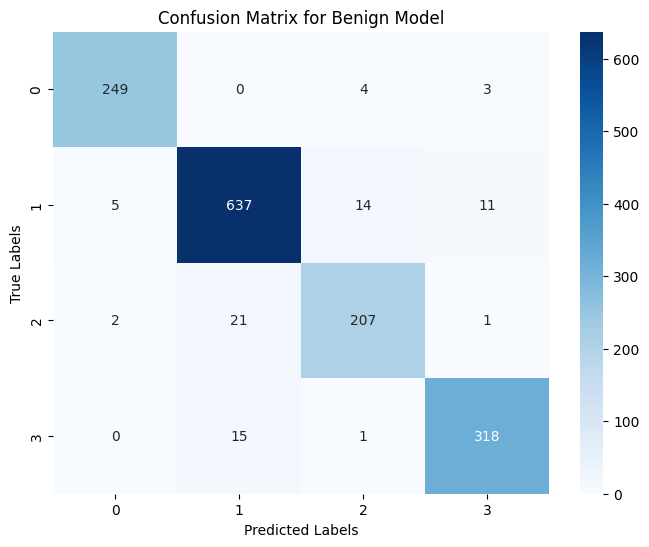

In [ ]:
conf_matrix_b = confusion_matrix(y_true_b, y_pred_b)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_b, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Confusion Matrix for Benign Model')
plt.show()

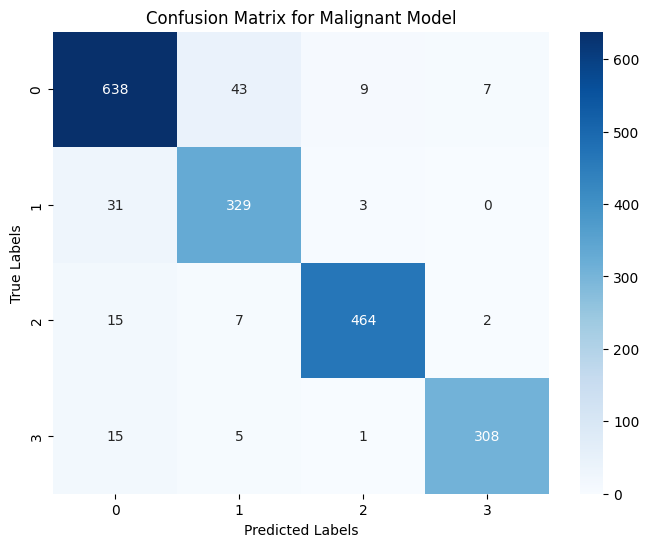

In [ ]:
conf_matrix_m = confusion_matrix(y_true_m, y_pred_m)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_m, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Confusion Matrix for Malignant Model')
plt.show()